In [1]:
# Task 5: Time Series Preprocessing & Forecasting
# NASA POWER Weather Data  Egypt
# 10 Years | All Governorates

import requests
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

In [2]:
# Cell 2 Egyptian Governorates and Coordinates

governorates = {
    "Cairo": (30.0444, 31.2357),
    "Alexandria": (31.2001, 29.9187),
    "Giza": (30.0131, 31.2089),
    "Qalyubia": (30.4667, 31.1833),
    "Port Said": (31.2653, 32.3019),
    "Suez": (29.9668, 32.5498),
    "Damietta": (31.4165, 31.8133),
    "Dakahlia": (31.0364, 31.3807),
    "Sharqia": (30.7327, 31.7195),
    "Gharbia": (30.8754, 31.0335),
    "Monufia": (30.5972, 30.9876),
    "Kafr El Sheikh": (31.1107, 30.9388),
    "Beheira": (30.8481, 30.3436),
    "Ismailia": (30.5965, 32.2715),
    "Fayoum": (29.3084, 30.8428),
    "Beni Suef": (29.0661, 31.0994),
    "Minya": (28.1099, 30.7503),
    "Asyut": (27.1783, 31.1859),
    "Sohag": (26.5591, 31.6957),
    "Qena": (26.1551, 32.7160),
    "Luxor": (25.6872, 32.6396),
    "Aswan": (24.0889, 32.8998),
    "Red Sea": (27.2579, 33.8116),
    "New Valley": (25.4500, 30.5500),
    "Matrouh": (31.3543, 27.2373),
    "North Sinai": (30.0444, 33.8284),
    "South Sinai": (28.4940, 34.0180)
}

print("Number of governorates:", len(governorates))

for governorate, (lat, lon) in governorates.items():
    print(f"{governorate}: ({lat}, {lon})")

Number of governorates: 27
Cairo: (30.0444, 31.2357)
Alexandria: (31.2001, 29.9187)
Giza: (30.0131, 31.2089)
Qalyubia: (30.4667, 31.1833)
Port Said: (31.2653, 32.3019)
Suez: (29.9668, 32.5498)
Damietta: (31.4165, 31.8133)
Dakahlia: (31.0364, 31.3807)
Sharqia: (30.7327, 31.7195)
Gharbia: (30.8754, 31.0335)
Monufia: (30.5972, 30.9876)
Kafr El Sheikh: (31.1107, 30.9388)
Beheira: (30.8481, 30.3436)
Ismailia: (30.5965, 32.2715)
Fayoum: (29.3084, 30.8428)
Beni Suef: (29.0661, 31.0994)
Minya: (28.1099, 30.7503)
Asyut: (27.1783, 31.1859)
Sohag: (26.5591, 31.6957)
Qena: (26.1551, 32.716)
Luxor: (25.6872, 32.6396)
Aswan: (24.0889, 32.8998)
Red Sea: (27.2579, 33.8116)
New Valley: (25.45, 30.55)
Matrouh: (31.3543, 27.2373)
North Sinai: (30.0444, 33.8284)
South Sinai: (28.494, 34.018)


In [3]:
# Cell 3  NASA POWER Configuration

START_DATE = "20150101"
END_DATE = "20241231"

# NASA POWER daily meteorological parameters
parameters = [
    "T2M",              # Temperature at 2 meters
    "T2M_MAX",          # Maximum temperature
    "T2M_MIN",          # Minimum temperature
    "RH2M",             # Relative humidity
    "PRECTOTCORR",      # Corrected precipitation
    "WS2M",             # Wind speed at 2 meters
    "WD2M",             # Wind direction at 2 meters
    "ALLSKY_SFC_SW_DWN", # All-sky surface shortwave downward irradiance
    "ALLSKY_SFC_LW_DWN", # All-sky surface longwave downward irradiance
    "ALLSKY_SFC_PAR_TOT",# All-sky PAR
    "CLRSKY_SFC_SW_DWN", # Clear-sky surface shortwave radiation
    "PS",                # Surface pressure
    "QV2M",              # Specific humidity at 2 meters
    "T2MDEW",            # Dew point temperature
    "T2MWET"             # Wet bulb temperature
]

print("Start date:", START_DATE)
print("End date:", END_DATE)
print("Number of parameters:", len(parameters))
print("\nParameters:")
for p in parameters:
    print("-", p)

Start date: 20150101
End date: 20241231
Number of parameters: 15

Parameters:
- T2M
- T2M_MAX
- T2M_MIN
- RH2M
- PRECTOTCORR
- WS2M
- WD2M
- ALLSKY_SFC_SW_DWN
- ALLSKY_SFC_LW_DWN
- ALLSKY_SFC_PAR_TOT
- CLRSKY_SFC_SW_DWN
- PS
- QV2M
- T2MDEW
- T2MWET


In [4]:
# Cell 4 Test NASA POWER API with Cairo

BASE_URL = "https://power.larc.nasa.gov/api/temporal/daily/point"

test_governorate = "Cairo"
test_lat, test_lon = governorates[test_governorate]

params = {
    "parameters": ",".join(parameters),
    "community": "RE",
    "longitude": test_lon,
    "latitude": test_lat,
    "start": START_DATE,
    "end": END_DATE,
    "format": "JSON"
}

response = requests.get(BASE_URL, params=params)

print("Status code:", response.status_code)

if response.status_code == 200:
    print("API request successful!")
else:
    print("API request failed.")
    print(response.text[:1000])

Status code: 200
API request successful!


In [5]:
# Cell 5  Inspect NASA POWER Response

data = response.json()

print("Top-level keys:")
print(data.keys())

print("\nParameter keys returned:")
print(data["properties"]["parameter"].keys())

print("\nNumber of dates returned:")
print(len(data["properties"]["parameter"]["T2M"]))

print("\nFirst 5 T2M values:")
first_values = list(data["properties"]["parameter"]["T2M"].items())[:5]
print(first_values)

print("\nFirst 5 dates:")
print(list(data["properties"]["parameter"]["T2M"].keys())[:5])

print("\nLast 5 dates:")
print(list(data["properties"]["parameter"]["T2M"].keys())[-5:])

Top-level keys:
dict_keys(['type', 'geometry', 'properties', 'header', 'messages', 'parameters', 'times'])

Parameter keys returned:
dict_keys(['T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M', 'WD2M', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_PAR_TOT', 'CLRSKY_SFC_SW_DWN', 'PS', 'QV2M', 'T2MDEW', 'T2MWET'])

Number of dates returned:
3653

First 5 T2M values:
[('20150101', 9.89), ('20150102', 9.47), ('20150103', 9.08), ('20150104', 10.1), ('20150105', 10.97)]

First 5 dates:
['20150101', '20150102', '20150103', '20150104', '20150105']

Last 5 dates:
['20241227', '20241228', '20241229', '20241230', '20241231']


In [6]:
# Cell 6 — Download Weather Data for All Egyptian Governorates

all_data = []

for governorate, (lat, lon) in governorates.items():

    print(f"Downloading: {governorate}...")

    params = {
        "parameters": ",".join(parameters),
        "community": "RE",
        "longitude": lon,
        "latitude": lat,
        "start": START_DATE,
        "end": END_DATE,
        "format": "JSON"
    }

    response = requests.get(BASE_URL, params=params)

    if response.status_code != 200:
        print(f"ERROR for {governorate}: Status {response.status_code}")
        continue

    data = response.json()
    weather = data["properties"]["parameter"]

    temp_df = pd.DataFrame(weather)
    temp_df.index.name = "Date"
    temp_df = temp_df.reset_index()

    temp_df["Date"] = pd.to_datetime(temp_df["Date"], format="%Y%m%d")
    temp_df["Governorate"] = governorate

    all_data.append(temp_df)

print("\nDownload complete!")

# Combine all governorates
weather_df = pd.concat(all_data, ignore_index=True)

print("\nDataset shape:", weather_df.shape)
print("\nGovernorates downloaded:", weather_df["Governorate"].nunique())
print("\nRows per governorate:")
print(weather_df.groupby("Governorate").size())

Downloading: Cairo...
Downloading: Alexandria...
Downloading: Giza...
Downloading: Qalyubia...
Downloading: Port Said...
Downloading: Suez...
Downloading: Damietta...
Downloading: Dakahlia...
Downloading: Sharqia...
Downloading: Gharbia...
Downloading: Monufia...
Downloading: Kafr El Sheikh...
Downloading: Beheira...
Downloading: Ismailia...
Downloading: Fayoum...
Downloading: Beni Suef...
Downloading: Minya...
Downloading: Asyut...
Downloading: Sohag...
Downloading: Qena...
Downloading: Luxor...
Downloading: Aswan...
Downloading: Red Sea...
Downloading: New Valley...
Downloading: Matrouh...
Downloading: North Sinai...
Downloading: South Sinai...

Download complete!

Dataset shape: (98631, 17)

Governorates downloaded: 27

Rows per governorate:
Governorate
Alexandria        3653
Aswan             3653
Asyut             3653
Beheira           3653
Beni Suef         3653
Cairo             3653
Dakahlia          3653
Damietta          3653
Fayoum            3653
Gharbia           3653
Giz

In [7]:
# Cell 7 Save Raw Dataset

raw_file = "egypt_weather_2015_2024_raw.csv"

weather_df.to_csv(raw_file, index=False)

print(f"Raw dataset saved as: {raw_file}")
print(f"Rows: {len(weather_df):,}")
print(f"Columns: {len(weather_df.columns)}")

Raw dataset saved as: egypt_weather_2015_2024_raw.csv
Rows: 98,631
Columns: 17


In [8]:
# Cell 8  Initial Data Inspection

print("=== FIRST 5 ROWS ===")
display(weather_df.head())

print("\n=== DATASET INFO ===")
weather_df.info()

print("\n=== DATA TYPES ===")
print(weather_df.dtypes)

print("\n=== MISSING VALUES ===")
print(weather_df.isna().sum())

print("\n=== DUPLICATE ROWS ===")
print("Duplicate rows:", weather_df.duplicated().sum())

print("\n=== DUPLICATE DATE-GOVERNORATE PAIRS ===")
print(
    weather_df.duplicated(
        subset=["Date", "Governorate"]
    ).sum()
)

print("\n=== DATE RANGE ===")
print("Start:", weather_df["Date"].min())
print("End:", weather_df["Date"].max())

print("\n=== GOVERNORATES ===")
print("Count:", weather_df["Governorate"].nunique())
print(sorted(weather_df["Governorate"].unique()))

=== FIRST 5 ROWS ===


,Date,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,WD2M,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_PAR_TOT,CLRSKY_SFC_SW_DWN,PS,QV2M,T2MDEW,T2MWET,Governorate
0,2015-01-01,9.89,15.67,5.04,37.82,0.00,2.79,285.0,2.8922,7.0942,1.2185,2.9254,100.55,2.73,-4.47,2.71,Cairo
1,2015-01-02,9.47,17.58,3.27,50.61,0.00,1.77,307.2,3.3962,7.0606,1.4947,3.6703,100.72,3.62,-0.81,4.33,Cairo
2,2015-01-03,9.08,16.73,3.47,41.40,0.01,2.76,286.9,3.6372,6.9072,1.5614,3.7114,100.68,2.76,-4.63,2.23,Cairo
3,2015-01-04,10.10,17.62,4.90,64.28,0.10,2.76,268.2,3.2117,7.1801,1.4213,3.7968,100.56,4.71,2.85,6.48,Cairo
4,2015-01-05,10.97,17.23,5.42,65.41,0.01,5.10,219.5,3.0482,7.6934,1.3514,3.4824,100.05,5.20,4.34,7.66,Cairo



=== DATASET INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98631 entries, 0 to 98630
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Date                98631 non-null  datetime64[ns]
 1   T2M                 98631 non-null  float64       
 2   T2M_MAX             98631 non-null  float64       
 3   T2M_MIN             98631 non-null  float64       
 4   RH2M                98631 non-null  float64       
 5   PRECTOTCORR         98631 non-null  float64       
 6   WS2M                98631 non-null  float64       
 7   WD2M                98631 non-null  float64       
 8   ALLSKY_SFC_SW_DWN   98631 non-null  float64       
 9   ALLSKY_SFC_LW_DWN   98631 non-null  float64       
 10  ALLSKY_SFC_PAR_TOT  98631 non-null  float64       
 11  CLRSKY_SFC_SW_DWN   98631 non-null  float64       
 12  PS                  98631 non-null  float64       
 13  QV2M                9863

In [9]:
# Cell 9 Check Daily Frequency and Missing Dates

frequency_results = []

for governorate, group in weather_df.groupby("Governorate"):

    dates = group["Date"].sort_values()

    full_range = pd.date_range(
        start=dates.min(),
        end=dates.max(),
        freq="D"
    )

    missing_dates = full_range.difference(dates)

    frequency_results.append({
        "Governorate": governorate,
        "Rows": len(group),
        "Start": dates.min(),
        "End": dates.max(),
        "Expected Days": len(full_range),
        "Missing Dates": len(missing_dates),
        "Duplicate Dates": dates.duplicated().sum(),
        "Inferred Frequency": pd.infer_freq(dates)
    })

frequency_check = pd.DataFrame(frequency_results)

display(frequency_check)

print("\n=== SUMMARY ===")
print("Governorates checked:", len(frequency_check))
print("Governorates with missing dates:",
      (frequency_check["Missing Dates"] > 0).sum())
print("Governorates with duplicates:",
      (frequency_check["Duplicate Dates"] > 0).sum())
print("Frequency values found:",
      frequency_check["Inferred Frequency"].unique())

,Governorate,Rows,Start,End,Expected Days,Missing Dates,Duplicate Dates,Inferred Frequency
0,Alexandria,3653,2015-01-01,2024-12-31,3653,0,0,D
1,Aswan,3653,2015-01-01,2024-12-31,3653,0,0,D
2,Asyut,3653,2015-01-01,2024-12-31,3653,0,0,D
3,Beheira,3653,2015-01-01,2024-12-31,3653,0,0,D
4,Beni Suef,3653,2015-01-01,2024-12-31,3653,0,0,D
5,Cairo,3653,2015-01-01,2024-12-31,3653,0,0,D
6,Dakahlia,3653,2015-01-01,2024-12-31,3653,0,0,D
7,Damietta,3653,2015-01-01,2024-12-31,3653,0,0,D
8,Fayoum,3653,2015-01-01,2024-12-31,3653,0,0,D
9,Gharbia,3653,2015-01-01,2024-12-31,3653,0,0,D



=== SUMMARY ===
Governorates checked: 27
Governorates with missing dates: 0
Governorates with duplicates: 0
Frequency values found: ['D']


In [10]:
# Cell 10  Prepare Time-Series Index

weather_ts = weather_df.copy()

weather_ts = weather_ts.sort_values(
    ["Governorate", "Date"]
)

weather_ts = weather_ts.set_index(
    ["Governorate", "Date"]
)

print("Index names:", weather_ts.index.names)
print("Shape:", weather_ts.shape)

display(weather_ts.head(10))

Index names: ['Governorate', 'Date']
Shape: (98631, 15)


T2M  T2M_MAX  T2M_MIN   RH2M  PRECTOTCORR  WS2M   WD2M  ALLSKY_SFC_SW_DWN  ALLSKY_SFC_LW_DWN  ALLSKY_SFC_PAR_TOT  CLRSKY_SFC_SW_DWN      PS  QV2M  T2MDEW  T2MWET
Governorate Date                                                                                                                                                                           
Alexandria  2015-01-01  12.45    16.02     9.68  56.39         0.00  5.15  265.5             2.4096             8.0064              1.0397             2.4958  102.00  4.90    3.46    7.96
            2015-01-02  13.27    18.69     9.88  63.14         0.00  3.33  279.3             3.1130             7.7940              1.3858             3.3982  102.22  5.73    5.88    9.57
            2015-01-03  13.32    17.58     9.76  58.45         0.78  4.35  281.8             2.8814             7.9066              1.2802             3.4546  102.17  5.30    4.51    8.92
            2015-01-04  13.86    17.49    11.35  66.23         0.11  3.53  280.6             3.1310             8.0155              1.4114             3.6646  101.99  6.31    7.31   10.59
            2015-01-05  13.62    17.49     9.76  66.89         0.09  6.86  229.1             2.3786             8.5253              1.0922             2.9443  101.30  6.31    7.11   10.36
            2015-01-06  12.18    13.99     9.31  59.40         2.39  8.64  252.8             1.5401             8.6719              0.7178             2.7394  101.15  5.20    4.25    8.22
            2015-01-07  10.79    12.82     8.25  63.97        10.78  7.87  287.8             1.8559             8.4619              0.8486             3.4231  101.73  5.04    4.04    7.42
            2015-01-08  11.20    12.56    10.24  59.95         0.62  6.48  318.1             2.0491             8.3407              0.9341             3.6941  102.58  4.84    3.61    7.40
            2015-01-09  11.33    13.47     7.89  60.96         0.77  6.08  332.0             1.6308             8.3530              0.7373             3.7356  102.55  4.93    3.83    7.58
            2015-01-10  12.52    15.63     7.82  69.14         3.07  4.11  272.3             2.0069             8.3194              0.9326             3.6497  102.22  6.10    6.74    9.63

In [11]:
# Cell 11  Descriptive Statistics

weather_ts.describe().T

,count,mean,std,min,25%,50%,75%,max
T2M,98631.0,22.714244,6.910189,2.9800,16.7700,23.2200,28.6800,39.5100
T2M_MAX,98631.0,29.715081,7.901148,7.3400,23.0300,29.6800,36.6200,48.5300
T2M_MIN,98631.0,16.750985,6.414815,-2.3800,11.4600,17.4000,22.2000,33.0500
RH2M,98631.0,50.418695,17.607065,5.7500,37.8800,52.4800,64.2100,95.7900
PRECTOTCORR,98631.0,0.254903,2.254423,0.0000,0.0000,0.0000,0.0000,333.0200
WS2M,98631.0,3.181231,1.231819,0.5600,2.3600,3.0000,3.7800,12.5100
WD2M,98631.0,236.422170,129.417469,0.0000,85.7500,308.8000,333.6000,360.0000
ALLSKY_SFC_SW_DWN,98631.0,5.912669,1.776531,0.5666,4.3721,6.1495,7.5521,8.8315
ALLSKY_SFC_LW_DWN,98631.0,8.370173,0.877845,5.9434,7.6786,8.4427,9.1027,10.9562
ALLSKY_SFC_PAR_TOT,98631.0,2.638856,0.794050,0.3072,1.9391,2.7451,3.3770,3.9706


In [12]:
# Check minimum and maximum values of every feature

summary = pd.DataFrame({
    "Min": weather_ts.min(),
    "Max": weather_ts.max(),
    "Mean": weather_ts.mean(),
    "Std": weather_ts.std()
})

display(summary)

,Min,Max,Mean,Std
T2M,2.9800,39.5100,22.714244,6.910189
T2M_MAX,7.3400,48.5300,29.715081,7.901148
T2M_MIN,-2.3800,33.0500,16.750985,6.414815
RH2M,5.7500,95.7900,50.418695,17.607065
PRECTOTCORR,0.0000,333.0200,0.254903,2.254423
WS2M,0.5600,12.5100,3.181231,1.231819
WD2M,0.0000,360.0000,236.422170,129.417469
ALLSKY_SFC_SW_DWN,0.5666,8.8315,5.912669,1.776531
ALLSKY_SFC_LW_DWN,5.9434,10.9562,8.370173,0.877845
ALLSKY_SFC_PAR_TOT,0.3072,3.9706,2.638856,0.794050


In [13]:
# Cell 12 — Physical Validity Checks

checks = {}

checks["T2M < -50°C"] = (weather_ts["T2M"] < -50).sum()
checks["T2M > 60°C"] = (weather_ts["T2M"] > 60).sum()

checks["T2M_MAX < T2M_MIN"] = (
    weather_ts["T2M_MAX"] < weather_ts["T2M_MIN"]
).sum()

checks["T2M_MAX < T2M"] = (
    weather_ts["T2M_MAX"] < weather_ts["T2M"]
).sum()

checks["T2M_MIN > T2M"] = (
    weather_ts["T2M_MIN"] > weather_ts["T2M"]
).sum()

checks["RH2M < 0%"] = (weather_ts["RH2M"] < 0).sum()
checks["RH2M > 100%"] = (weather_ts["RH2M"] > 100).sum()

checks["PRECTOTCORR < 0"] = (
    weather_ts["PRECTOTCORR"] < 0
).sum()

checks["WS2M < 0"] = (
    weather_ts["WS2M"] < 0
).sum()

checks["WD2M < 0"] = (
    weather_ts["WD2M"] < 0
).sum()

checks["WD2M > 360"] = (
    weather_ts["WD2M"] > 360
).sum()

checks["PS <= 0"] = (
    weather_ts["PS"] <= 0
).sum()

checks["QV2M < 0"] = (
    weather_ts["QV2M"] < 0
).sum()

pd.DataFrame.from_dict(
    checks,
    orient="index",
    columns=["Number of violations"]
)

,Number of violations
T2M < -50°C,0
T2M > 60°C,0
T2M_MAX < T2M_MIN,0
T2M_MAX < T2M,0
T2M_MIN > T2M,0
RH2M < 0%,0
RH2M > 100%,0
PRECTOTCORR < 0,0
WS2M < 0,0
WD2M < 0,0


In [14]:
# Cell 13 Seasonal-Aware Outlier Detection for Temperature

outlier_df = weather_df[
    ["Governorate", "Date", "T2M"]
].copy()

outlier_df = outlier_df.sort_values(
    ["Governorate", "Date"]
)

# Rolling median
outlier_df["rolling_median"] = (
    outlier_df
    .groupby("Governorate")["T2M"]
    .transform(
        lambda x: x.rolling(
            window=31,
            center=True,
            min_periods=15
        ).median()
    )
)

# Rolling MAD
outlier_df["rolling_mad"] = (
    outlier_df
    .groupby("Governorate")["T2M"]
    .transform(
        lambda x: x.rolling(
            window=31,
            center=True,
            min_periods=15
        ).apply(
            lambda y: np.median(
                np.abs(y - np.median(y))
            ),
            raw=True
        )
    )
)

# Robust rolling z-score
outlier_df["robust_z"] = (
    0.6745
    * (outlier_df["T2M"] - outlier_df["rolling_median"])
    / outlier_df["rolling_mad"].replace(0, np.nan)
)

# Flag strong local anomalies
outlier_df["is_outlier"] = (
    outlier_df["robust_z"].abs() > 3.5
)

print("Total observations:", len(outlier_df))
print("Potential temperature outliers:",
      outlier_df["is_outlier"].sum())

print("\nOutlier percentage:",
      round(
          outlier_df["is_outlier"].mean() * 100,
          3
      ),
      "%"
      )

Total observations: 98631
Potential temperature outliers: 493

Outlier percentage: 0.5 %


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load raw dataset
df = pd.read_csv('/content/egypt_weather_2015_2024_raw.csv')

# Convert Date
df['Date'] = pd.to_datetime(df['Date'])

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

df.head()

Dataset shape: (98631, 17)

Columns:
['Date', 'T2M', 'T2M_MAX', 'T2M_MIN', 'RH2M', 'PRECTOTCORR', 'WS2M', 'WD2M', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN', 'ALLSKY_SFC_PAR_TOT', 'CLRSKY_SFC_SW_DWN', 'PS', 'QV2M', 'T2MDEW', 'T2MWET', 'Governorate']


,Date,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,WD2M,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_PAR_TOT,CLRSKY_SFC_SW_DWN,PS,QV2M,T2MDEW,T2MWET,Governorate
0,2015-01-01,9.89,15.67,5.04,37.82,0.00,2.79,285.0,2.8922,7.0942,1.2185,2.9254,100.55,2.73,-4.47,2.71,Cairo
1,2015-01-02,9.47,17.58,3.27,50.61,0.00,1.77,307.2,3.3962,7.0606,1.4947,3.6703,100.72,3.62,-0.81,4.33,Cairo
2,2015-01-03,9.08,16.73,3.47,41.40,0.01,2.76,286.9,3.6372,6.9072,1.5614,3.7114,100.68,2.76,-4.63,2.23,Cairo
3,2015-01-04,10.10,17.62,4.90,64.28,0.10,2.76,268.2,3.2117,7.1801,1.4213,3.7968,100.56,4.71,2.85,6.48,Cairo
4,2015-01-05,10.97,17.23,5.42,65.41,0.01,5.10,219.5,3.0482,7.6934,1.3514,3.4824,100.05,5.20,4.34,7.66,Cairo


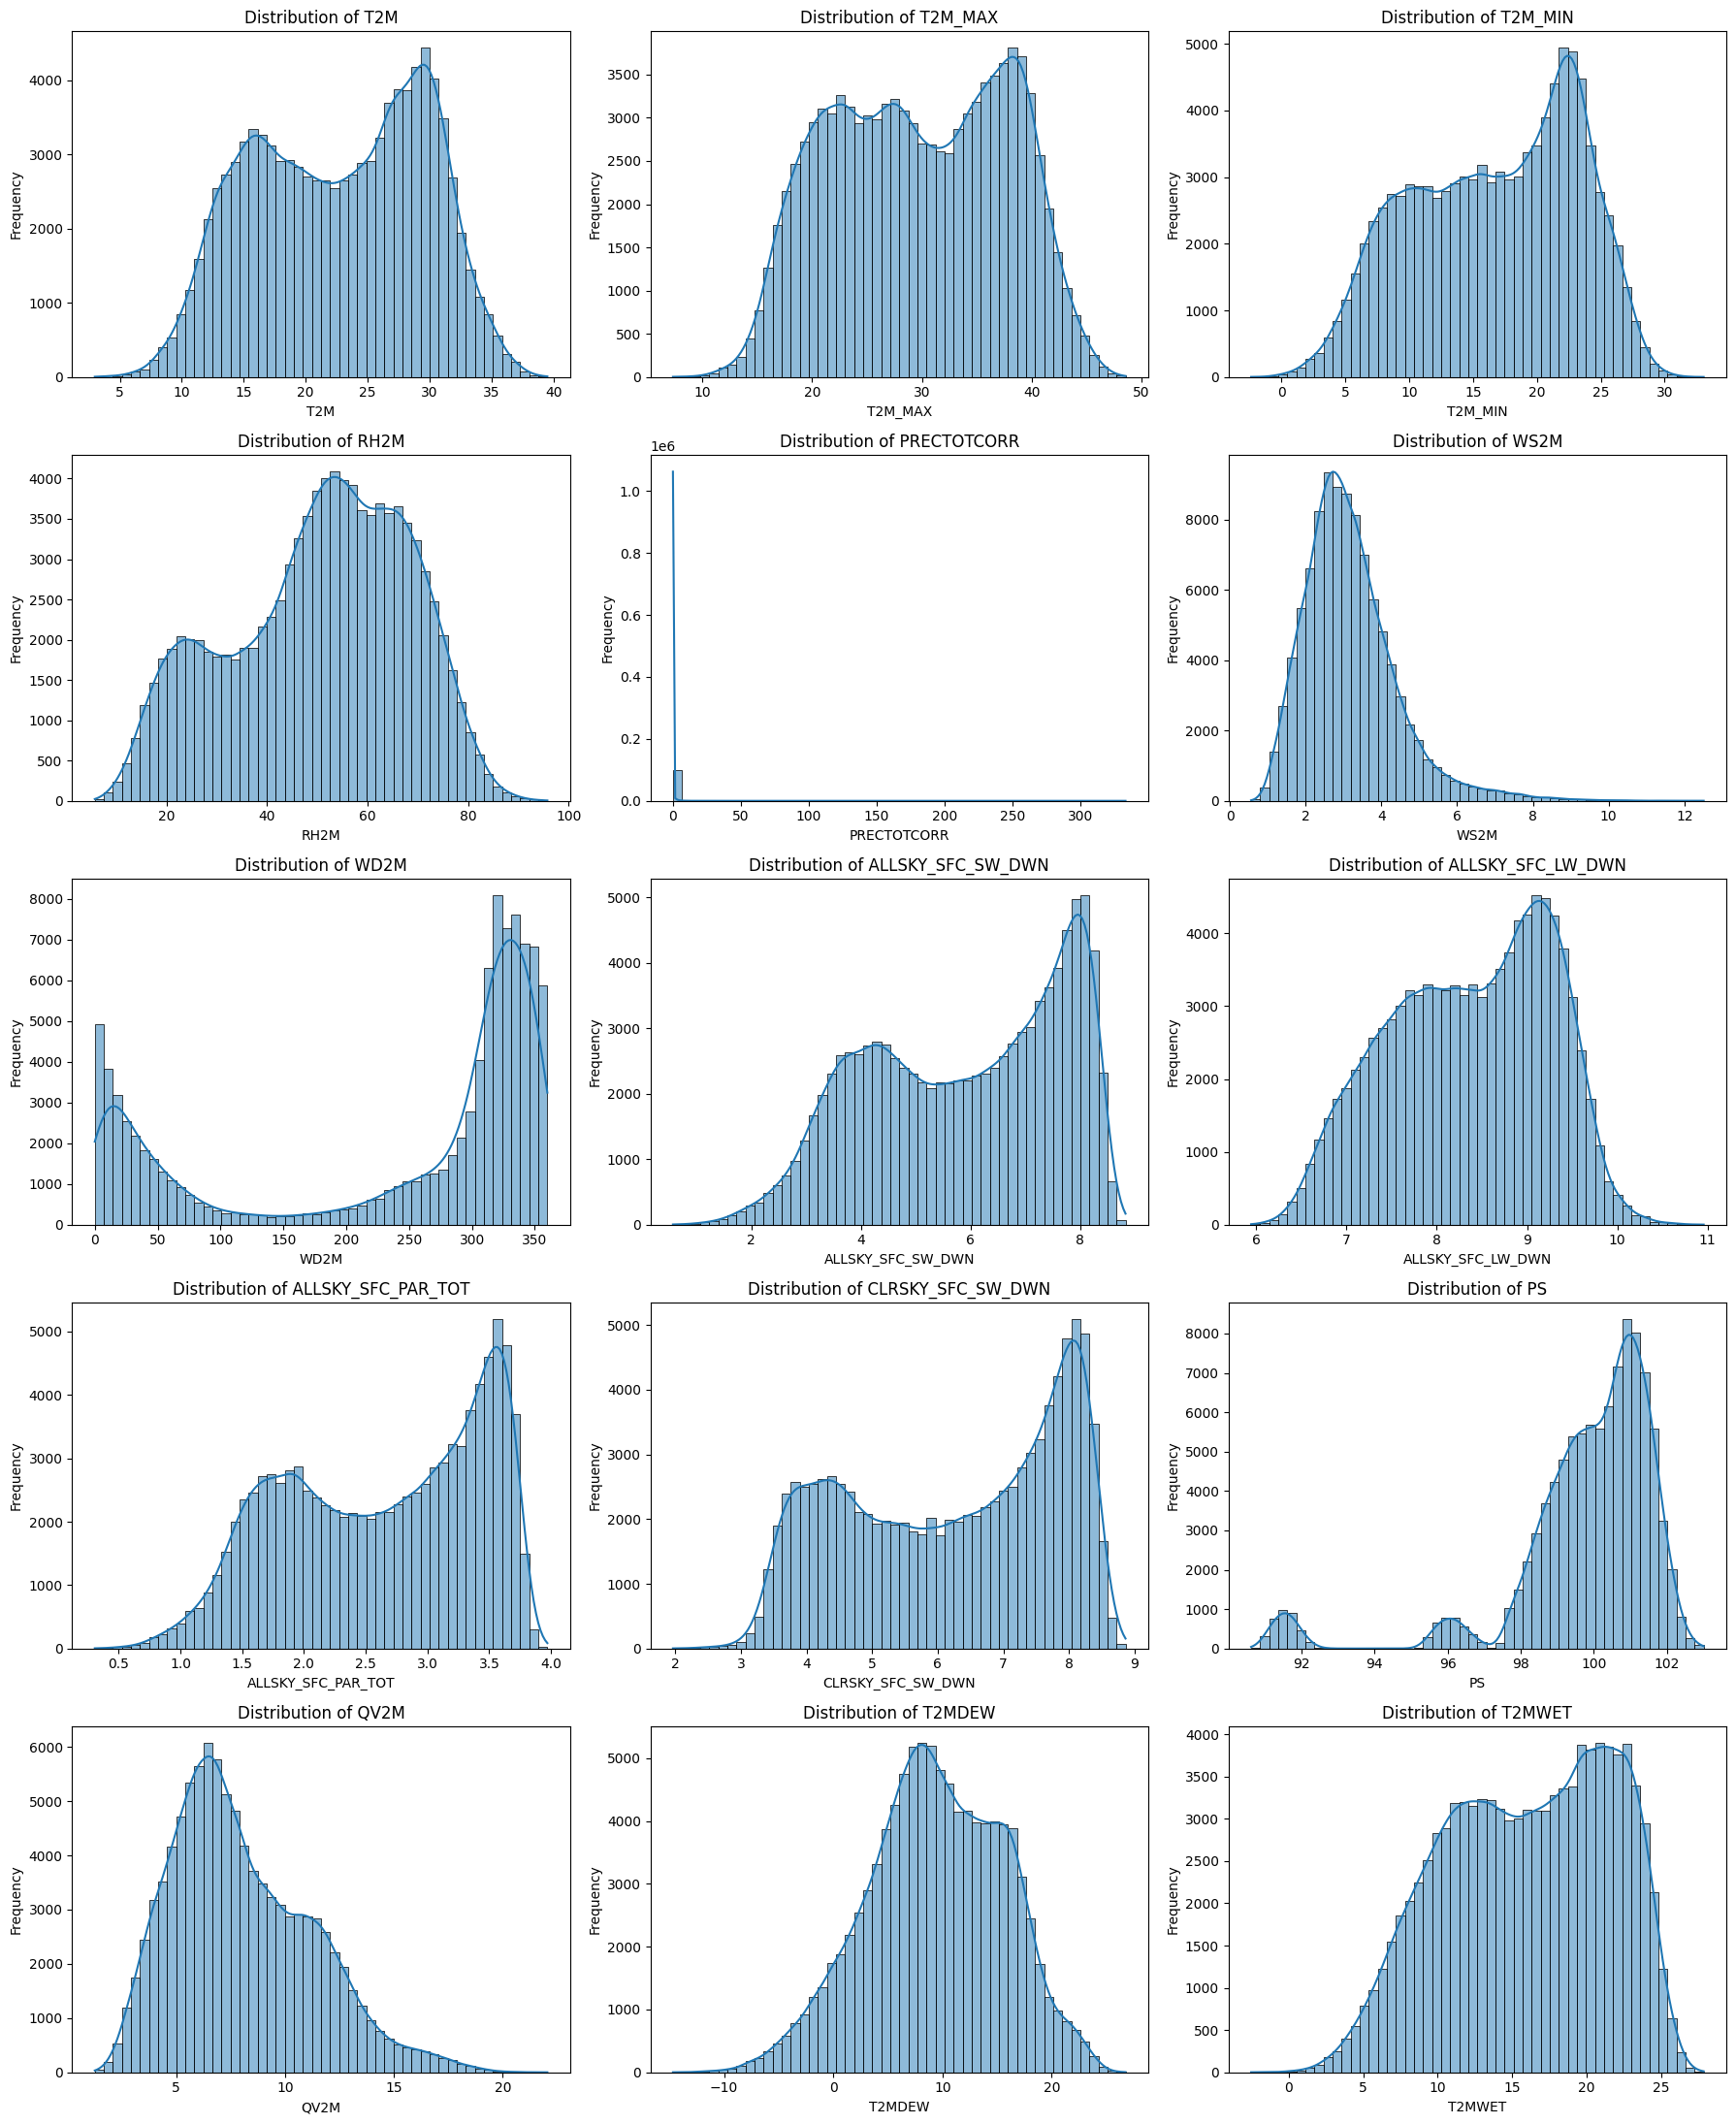

In [16]:
# EDA 1: Feature Distributions

import matplotlib.pyplot as plt
import seaborn as sns

# Numerical features
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Plot distributions
fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(18, 22)
)

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        df[col],
        bins=50,
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(f"Distribution of {col}")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# Hide unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [17]:
# Cell 2: Basic Dataset Overview

print("=== DATASET SHAPE ===")
print(df.shape)

print("\n=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
print(df.isnull().sum())

print("\n=== DUPLICATE ROWS ===")
print("Duplicate rows:", df.duplicated().sum())

print("\n=== DATE RANGE ===")
print("Start:", df['Date'].min())
print("End:", df['Date'].max())

print("\n=== GOVERNORATES ===")
print("Number:", df['Governorate'].nunique())
print(sorted(df['Governorate'].unique()))

print("\n=== ROWS PER GOVERNORATE ===")
print(df['Governorate'].value_counts().sort_index())

=== DATASET SHAPE ===
(98631, 17)

=== DATA TYPES ===
Date                  datetime64[ns]
T2M                          float64
T2M_MAX                      float64
T2M_MIN                      float64
RH2M                         float64
PRECTOTCORR                  float64
WS2M                         float64
WD2M                         float64
ALLSKY_SFC_SW_DWN            float64
ALLSKY_SFC_LW_DWN            float64
ALLSKY_SFC_PAR_TOT           float64
CLRSKY_SFC_SW_DWN            float64
PS                           float64
QV2M                         float64
T2MDEW                       float64
T2MWET                       float64
Governorate                   object
dtype: object

=== MISSING VALUES ===
Date                  0
T2M                   0
T2M_MAX               0
T2M_MIN               0
RH2M                  0
PRECTOTCORR           0
WS2M                  0
WD2M                  0
ALLSKY_SFC_SW_DWN     0
ALLSKY_SFC_LW_DWN     0
ALLSKY_SFC_PAR_TOT    0
CLRSKY_SFC_SW_D

=== CORRELATION MATRIX ===


,T2M,T2M_MAX,T2M_MIN,RH2M,PRECTOTCORR,WS2M,WD2M,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_LW_DWN,ALLSKY_SFC_PAR_TOT,CLRSKY_SFC_SW_DWN,PS,QV2M,T2MDEW,T2MWET
T2M,1.00,0.95,0.94,-0.53,-0.10,0.15,0.12,0.71,0.86,0.73,0.69,-0.16,0.44,0.41,0.86
T2M_MAX,0.95,1.00,0.78,-0.65,-0.13,-0.01,0.06,0.73,0.74,0.74,0.70,-0.22,0.25,0.22,0.72
T2M_MIN,0.94,0.78,1.00,-0.30,-0.07,0.28,0.15,0.57,0.90,0.60,0.57,-0.05,0.64,0.61,0.93
RH2M,-0.53,-0.65,-0.30,1.00,0.13,0.05,-0.11,-0.52,-0.19,-0.51,-0.48,0.49,0.48,0.53,-0.04
PRECTOTCORR,-0.10,-0.13,-0.07,0.13,1.00,0.07,-0.00,-0.14,-0.01,-0.14,-0.10,0.05,0.01,0.02,-0.05
WS2M,0.15,-0.01,0.28,0.05,0.07,1.00,0.17,0.13,0.21,0.14,0.17,0.04,0.23,0.22,0.22
WD2M,0.12,0.06,0.15,-0.11,-0.00,0.17,1.00,0.13,0.11,0.14,0.14,-0.08,0.05,0.03,0.09
ALLSKY_SFC_SW_DWN,0.71,0.73,0.57,-0.52,-0.14,0.13,0.13,1.00,0.44,1.00,0.96,-0.25,0.19,0.14,0.52
ALLSKY_SFC_LW_DWN,0.86,0.74,0.90,-0.19,-0.01,0.21,0.11,0.44,1.00,0.48,0.50,-0.01,0.65,0.64,0.90
ALLSKY_SFC_PAR_TOT,0.73,0.74,0.60,-0.51,-0.14,0.14,0.14,1.00,0.48,1.00,0.96,-0.24,0.23,0.18,0.56


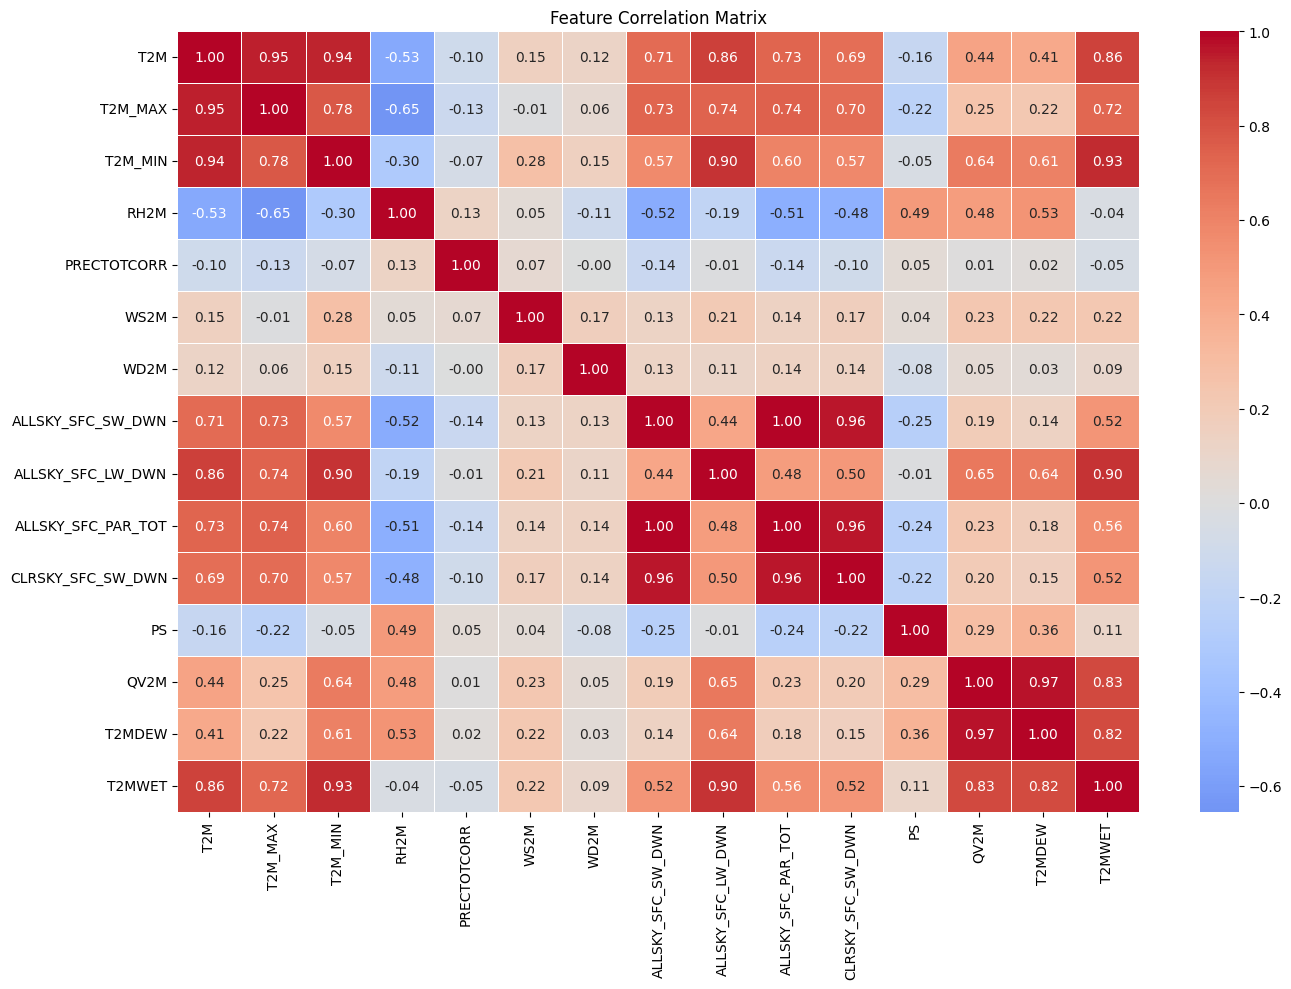

In [18]:
# EDA 2: Correlation Analysis

# Numerical columns only
numeric_cols = df.select_dtypes(include=np.number).columns.tolist()

# Pearson correlation matrix
corr_matrix = df[numeric_cols].corr()

print("=== CORRELATION MATRIX ===")
display(corr_matrix.round(2))

# Heatmap
plt.figure(figsize=(14, 10))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    linewidths=0.5
)

plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

In [19]:
# Highly Correlated Feature Pairs

corr_pairs = (
    corr_matrix
    .where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    .stack()
    .reset_index()
)

corr_pairs.columns = ["Feature 1", "Feature 2", "Correlation"]

# Sort by absolute correlation
corr_pairs["Abs Correlation"] = corr_pairs["Correlation"].abs()

high_corr = (
    corr_pairs[corr_pairs["Abs Correlation"] >= 0.80]
    .sort_values("Abs Correlation", ascending=False)
)

print("=== HIGHLY CORRELATED PAIRS (|r| >= 0.80) ===")
display(high_corr)

=== HIGHLY CORRELATED PAIRS (|r| >= 0.80) ===


,Feature 1,Feature 2,Correlation,Abs Correlation
78,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_PAR_TOT,0.998110,0.998110
102,QV2M,T2MDEW,0.973443,0.973443
90,ALLSKY_SFC_PAR_TOT,CLRSKY_SFC_SW_DWN,0.963803,0.963803
79,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,0.961434,0.961434
0,T2M,T2M_MAX,0.946688,0.946688
1,T2M,T2M_MIN,0.935593,0.935593
38,T2M_MIN,T2MWET,0.926235,0.926235
32,T2M_MIN,ALLSKY_SFC_LW_DWN,0.900926,0.900926
89,ALLSKY_SFC_LW_DWN,T2MWET,0.899483,0.899483
7,T2M,ALLSKY_SFC_LW_DWN,0.861171,0.861171


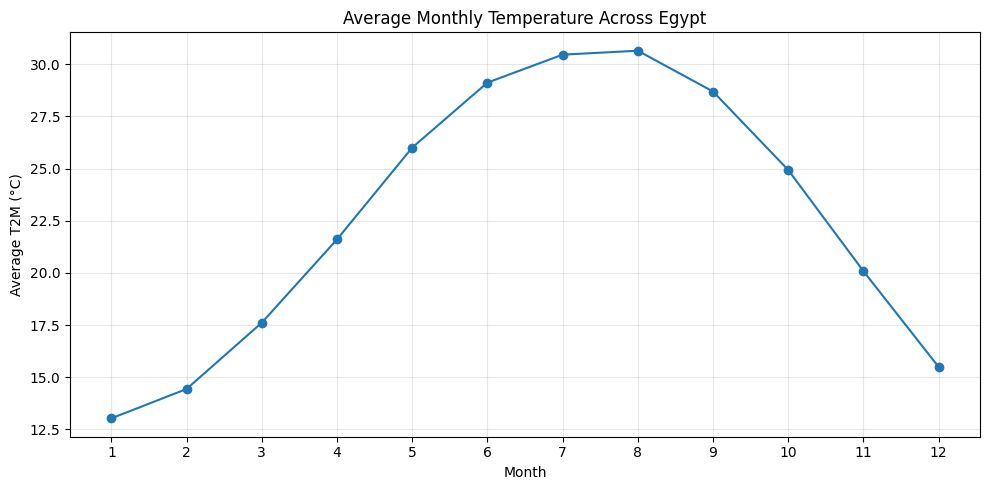

In [20]:
# Monthly Seasonal Pattern

monthly_temp = (
    df.assign(Month=df["Date"].dt.month)
      .groupby("Month")["T2M"]
      .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_temp.index,
    monthly_temp.values,
    marker="o"
)

plt.xticks(range(1, 13))
plt.xlabel("Month")
plt.ylabel("Average T2M (°C)")
plt.title("Average Monthly Temperature Across Egypt")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

,T2M
Year,
2015,22.480412
2016,22.672850
2017,22.163819
2018,23.116438
2019,22.506973
2020,22.421650
2021,22.896808
2022,22.267955
2023,23.353209


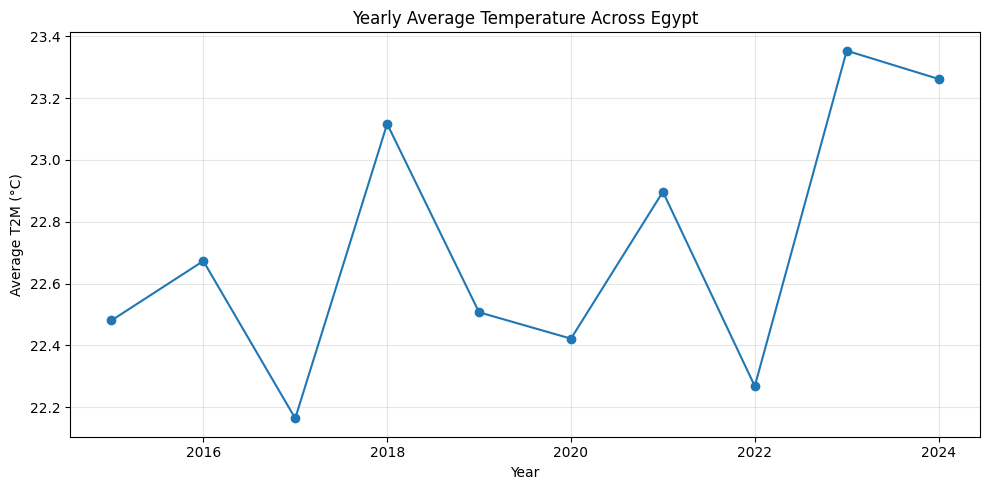

In [21]:
# Yearly Temperature Pattern

yearly_temp = (
    df.assign(Year=df["Date"].dt.year)
      .groupby("Year")["T2M"]
      .mean()
)

display(yearly_temp)

plt.figure(figsize=(10, 5))

plt.plot(
    yearly_temp.index,
    yearly_temp.values,
    marker="o"
)

plt.xlabel("Year")
plt.ylabel("Average T2M (°C)")
plt.title("Yearly Average Temperature Across Egypt")
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [22]:
# Features selected for removal after correlation analysis

features_to_remove = [
    "T2M_MAX",
    "T2M_MIN",
    "T2MWET",
    "ALLSKY_SFC_PAR_TOT",
    "WS2M",
    "WD2M"
]

weather_model_df = df.drop(columns=features_to_remove)

print("Removed features:")
print(features_to_remove)

print("\nRemaining columns:")
print(weather_model_df.columns.tolist())

print("\nNew shape:")
print(weather_model_df.shape)

display(weather_model_df.head())

Removed features:
['T2M_MAX', 'T2M_MIN', 'T2MWET', 'ALLSKY_SFC_PAR_TOT', 'WS2M', 'WD2M']

Remaining columns:
['Date', 'T2M', 'RH2M', 'PRECTOTCORR', 'ALLSKY_SFC_SW_DWN', 'ALLSKY_SFC_LW_DWN', 'CLRSKY_SFC_SW_DWN', 'PS', 'QV2M', 'T2MDEW', 'Governorate']

New shape:
(98631, 11)


,Date,T2M,RH2M,PRECTOTCORR,ALLSKY_SFC_SW_DWN,ALLSKY_SFC_LW_DWN,CLRSKY_SFC_SW_DWN,PS,QV2M,T2MDEW,Governorate
0,2015-01-01,9.89,37.82,0.00,2.8922,7.0942,2.9254,100.55,2.73,-4.47,Cairo
1,2015-01-02,9.47,50.61,0.00,3.3962,7.0606,3.6703,100.72,3.62,-0.81,Cairo
2,2015-01-03,9.08,41.40,0.01,3.6372,6.9072,3.7114,100.68,2.76,-4.63,Cairo
3,2015-01-04,10.10,64.28,0.10,3.2117,7.1801,3.7968,100.56,4.71,2.85,Cairo
4,2015-01-05,10.97,65.41,0.01,3.0482,7.6934,3.4824,100.05,5.20,4.34,Cairo


In [23]:
# Create one Egypt-wide daily temperature series

egypt_ts = (
    weather_model_df
    .groupby("Date")["T2M"]
    .mean()
    .sort_index()
)

egypt_ts = egypt_ts.asfreq("D")

print("Shape:", egypt_ts.shape)
print("Missing values:", egypt_ts.isna().sum())

display(egypt_ts.head())

Shape: (3653,)
Missing values: 0


,T2M
Date,
2015-01-01,12.496667
2015-01-02,11.764074
2015-01-03,11.258889
2015-01-04,11.133704
2015-01-05,11.675185


In [24]:
from statsmodels.tsa.stattools import adfuller, kpss

def stationarity_test(series, name="Series"):

    series = series.dropna()

    # ADF
    adf_result = adfuller(series)

    print(f"=== {name} ===")
    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"ADF p-value:   {adf_result[1]:.4f}")

    # KPSS
    kpss_result = kpss(series, regression="c", nlags="auto")

    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"KPSS p-value:   {kpss_result[1]:.4f}")

    print()

stationarity_test(egypt_ts, "Egypt T2M")

=== Egypt T2M ===
ADF Statistic: -3.9372
ADF p-value:   0.0018
KPSS Statistic: 0.0622
KPSS p-value:   0.1000



In [26]:
# Create Egypt-wide T2M Time Series

# Make sure Date is datetime
weather_model_df["Date"] = pd.to_datetime(weather_model_df["Date"])

# Average T2M across all governorates for each day
egypt_t2m = (
    weather_model_df
    .groupby("Date")["T2M"]
    .mean()
    .sort_index()
)

print("=== Egypt-wide T2M ===")
print("Shape:", egypt_t2m.shape)
print("Missing values:", egypt_t2m.isna().sum())
print("Start:", egypt_t2m.index.min())
print("End:", egypt_t2m.index.max())

display(egypt_t2m.head())

=== Egypt-wide T2M ===
Shape: (3653,)
Missing values: 0
Start: 2015-01-01 00:00:00
End: 2024-12-31 00:00:00


,T2M
Date,
2015-01-01,12.496667
2015-01-02,11.764074
2015-01-03,11.258889
2015-01-04,11.133704
2015-01-05,11.675185


In [27]:
# Stationarity Tests for Differencing
# Egypt-wide Daily T2M

from statsmodels.tsa.stattools import adfuller, kpss
import pandas as pd
import numpy as np

def stationarity_test(series, name):
    series = series.dropna()

    print("=" * 60)
    print(name)
    print("=" * 60)

    # ADF
    adf_result = adfuller(series, autolag="AIC")

    print(f"ADF Statistic: {adf_result[0]:.4f}")
    print(f"ADF p-value:   {adf_result[1]:.4f}")

    # KPSS
    kpss_result = kpss(series, regression="c", nlags="auto")

    print(f"KPSS Statistic: {kpss_result[0]:.4f}")
    print(f"KPSS p-value:   {kpss_result[1]:.4f}")

    # Interpretation
    print("\nInterpretation:")

    if adf_result[1] < 0.05:
        print("ADF  → Stationary")
    else:
        print("ADF  → Non-stationary")

    if kpss_result[1] > 0.05:
        print("KPSS → Stationary")
    else:
        print("KPSS → Non-stationary")

    print()


# Original series
ts = egypt_t2m.copy()

# Regular first difference
ts_diff1 = ts.diff(1).dropna()

# Seasonal difference: 365 days
ts_seasonal_diff = ts.diff(365).dropna()

# Both regular + seasonal difference
ts_both_diff = ts.diff(365).diff(1).dropna()


stationarity_test(
    ts,
    "Original T2M"
)

stationarity_test(
    ts_diff1,
    "First Difference: d = 1"
)

stationarity_test(
    ts_seasonal_diff,
    "Seasonal Difference: D = 1, s = 365"
)

stationarity_test(
    ts_both_diff,
    "First + Seasonal Difference: d = 1, D = 1, s = 365"
)

Original T2M
ADF Statistic: -3.9372
ADF p-value:   0.0018
KPSS Statistic: 0.0622
KPSS p-value:   0.1000

Interpretation:
ADF  → Stationary
KPSS → Stationary

First Difference: d = 1
ADF Statistic: -8.8080
ADF p-value:   0.0000
KPSS Statistic: 0.0446
KPSS p-value:   0.1000

Interpretation:
ADF  → Stationary
KPSS → Stationary

Seasonal Difference: D = 1, s = 365
ADF Statistic: -10.7136
ADF p-value:   0.0000
KPSS Statistic: 0.1084
KPSS p-value:   0.1000

Interpretation:
ADF  → Stationary
KPSS → Stationary

First + Seasonal Difference: d = 1, D = 1, s = 365
ADF Statistic: -18.1150
ADF p-value:   0.0000
KPSS Statistic: 0.0177
KPSS p-value:   0.1000

Interpretation:
ADF  → Stationary
KPSS → Stationary



this result is logical, and it actually tells us not to difference the series unnecessarily.

<Figure size 1400x600 with 0 Axes>

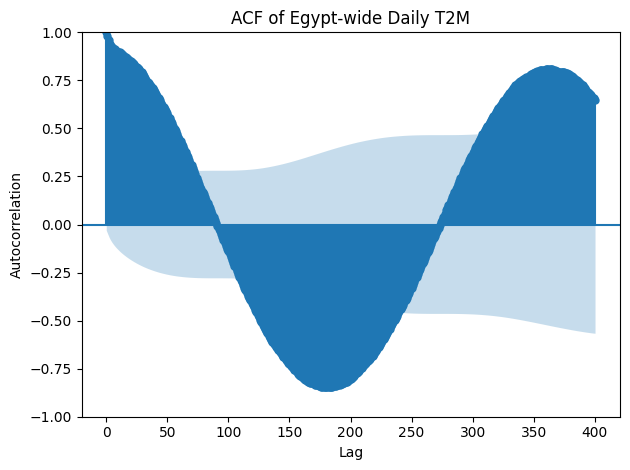

In [28]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

# Egypt-wide T2M
ts = (
    weather_model_df
    .groupby("Date")["T2M"]
    .mean()
    .sort_index()
)

plt.figure(figsize=(14, 6))

plot_acf(
    ts,
    lags=400,
    alpha=0.05
)

plt.title("ACF of Egypt-wide Daily T2M")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")

plt.tight_layout()
plt.show()

Shape: (3653,)
Missing values: 0


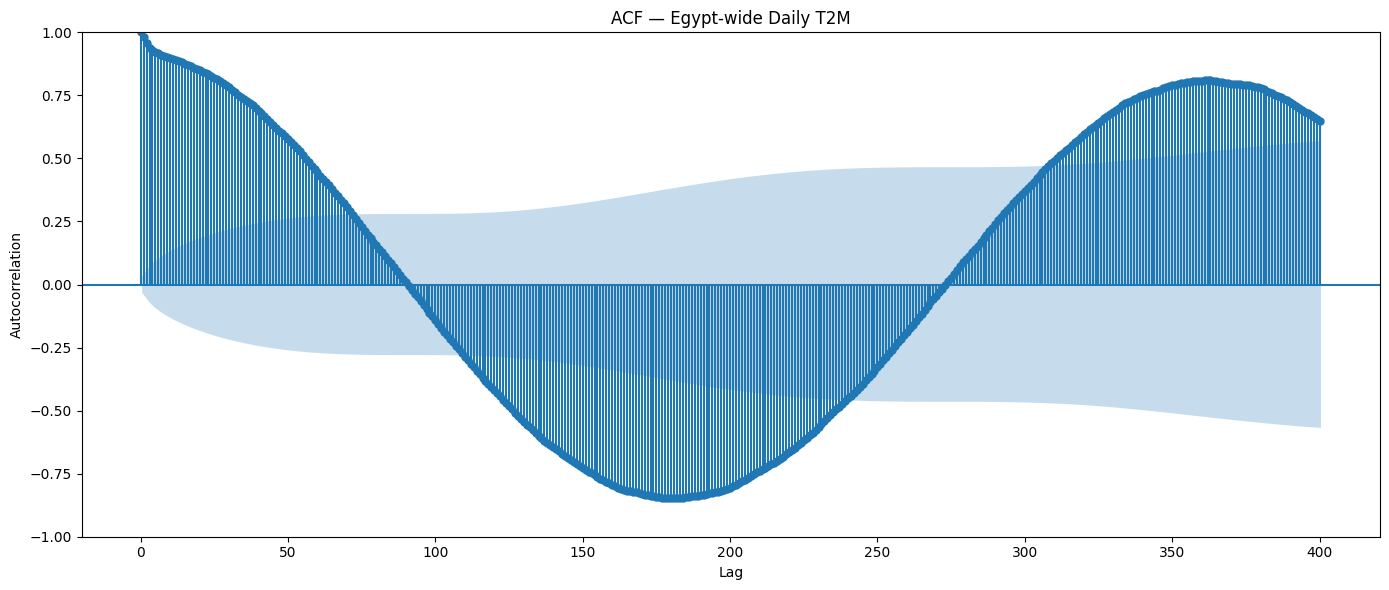

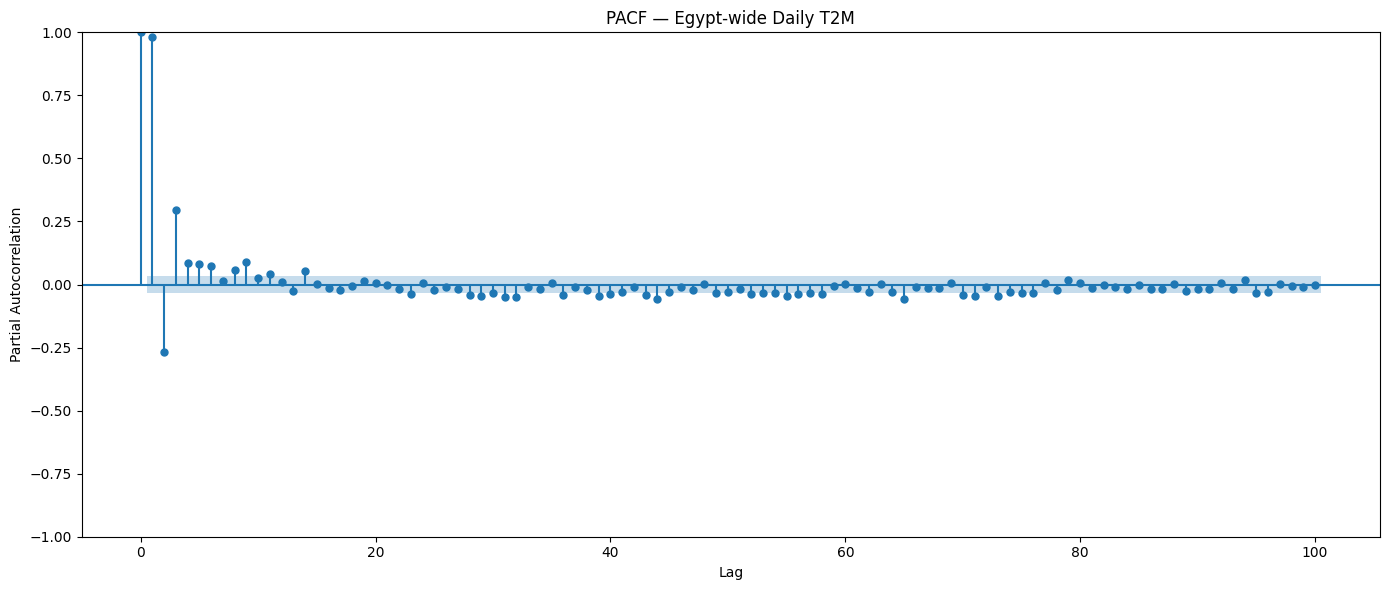

In [29]:
# ACF & PACF Analysis — Egypt-wide T2M

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Create Egypt-wide daily T2M series
egypt_t2m = (
    weather_model_df
    .groupby("Date")["T2M"]
    .mean()
    .sort_index()
)

print("Shape:", egypt_t2m.shape)
print("Missing values:", egypt_t2m.isna().sum())

# ACF

fig, ax = plt.subplots(figsize=(14, 6))

plot_acf(
    egypt_t2m,
    lags=400,
    alpha=0.05,
    ax=ax
)

ax.set_title("ACF — Egypt-wide Daily T2M")
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelation")

plt.tight_layout()
plt.show()


# PACF

fig, ax = plt.subplots(figsize=(14, 6))

plot_pacf(
    egypt_t2m,
    lags=100,
    alpha=0.05,
    method="ywm",
    ax=ax
)

ax.set_title("PACF — Egypt-wide Daily T2M")
ax.set_xlabel("Lag")
ax.set_ylabel("Partial Autocorrelation")

plt.tight_layout()
plt.show()

Strong ACF spike at 365 → annual seasonality exists → SARIMA is appropriate.

In [31]:
# ARIMA BASELINE
# Egypt-wide Daily T2M

from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# 1. Create Egypt-wide daily T2M
egypt_t2m = (
    df.groupby("Date")["T2M"]
      .mean()
      .sort_index()
)

egypt_t2m.index = pd.DatetimeIndex(egypt_t2m.index)

print("Shape:", egypt_t2m.shape)
print("Missing values:", egypt_t2m.isna().sum())

# 2. Train / Test split

# Last 365 days = test set
train = egypt_t2m.iloc[:-365]
test = egypt_t2m.iloc[-365:]

print("\nTrain period:")
print(train.index.min(), "→", train.index.max())

print("\nTest period:")
print(test.index.min(), "→", test.index.max())

print("\nTrain size:", len(train))
print("Test size:", len(test))

# 3. Fit ARIMA(1,0,1)

model = ARIMA(
    train,
    order=(1, 0, 1)
)

results = model.fit()

print("\n=== ARIMA(1,0,1) ===")
print(results.summary())

Shape: (3653,)
Missing values: 0

Train period:
2015-01-01 00:00:00 → 2024-01-01 00:00:00

Test period:
2024-01-02 00:00:00 → 2024-12-31 00:00:00

Train size: 3288
Test size: 365

=== ARIMA(1,0,1) ===
                               SARIMAX Results                                
Dep. Variable:                    T2M   No. Observations:                 3288
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5049.180
Date:                Fri, 07 Aug 2026   AIC                          10106.361
Time:                        19:11:50   BIC                          10130.753
Sample:                    01-01-2015   HQIC                         10115.094
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const    

In [33]:
# 4. Forecast the test period

forecast = results.forecast(
    steps=len(test)
)

forecast.index = test.index

# 5. Evaluation

mae = mean_absolute_error(
    test,
    forecast
)

rmse = np.sqrt(
    mean_squared_error(
        test,
        forecast
    )
)

print("===================================")
print("ARIMA(1,0,1) RESULTS")
print("===================================")
print(f"MAE : {mae:.4f}")
print(f"RMSE: {rmse:.4f}")

ARIMA(1,0,1) RESULTS
MAE : 5.4651
RMSE: 6.2855


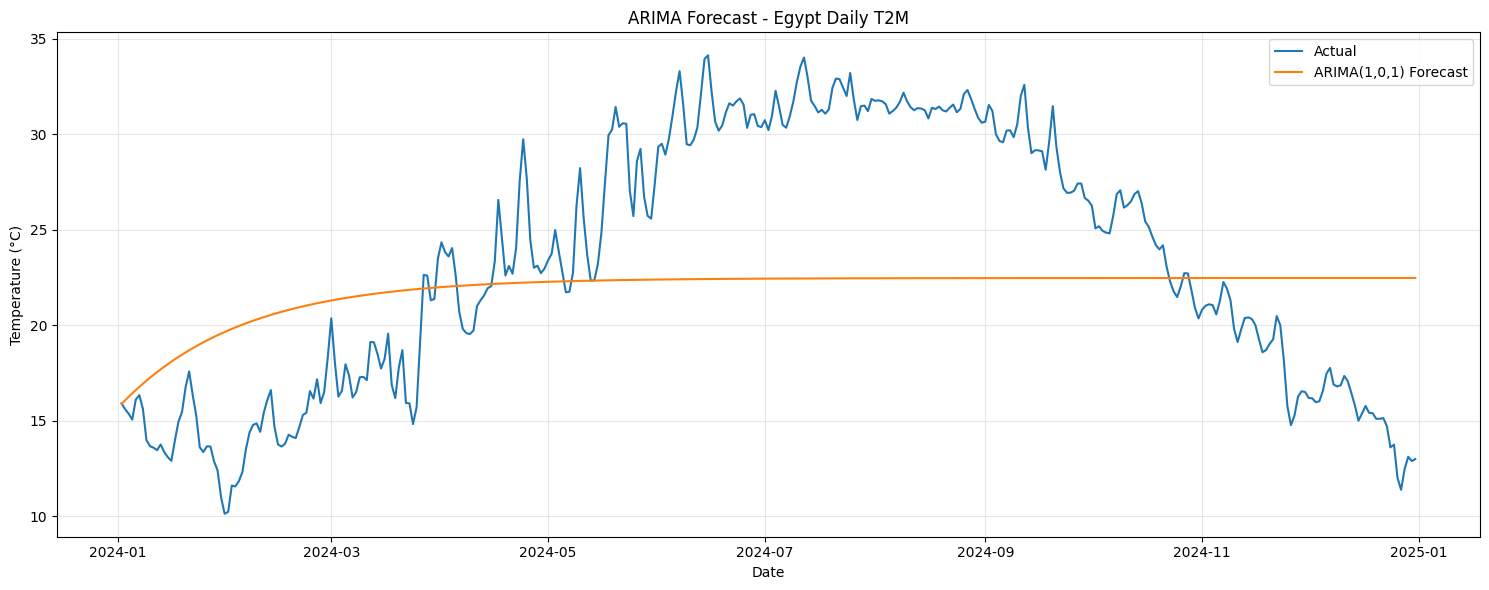

In [34]:
# 6. Actual vs Forecast

plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    forecast.index,
    forecast.values,
    label="ARIMA(1,0,1) Forecast"
)

plt.title("ARIMA Forecast - Egypt Daily T2M")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [35]:
print(results.summary())

print("\n==============================")
print("ARIMA(1,0,1) TEST PERFORMANCE")
print("==============================")
print(f"MAE  = {mae:.4f} °C")
print(f"RMSE = {rmse:.4f} °C")

                               SARIMAX Results                                
Dep. Variable:                    T2M   No. Observations:                 3288
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -5049.180
Date:                Fri, 07 Aug 2026   AIC                          10106.361
Time:                        19:14:29   BIC                          10130.753
Sample:                    01-01-2015   HQIC                         10115.094
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         22.4791      1.017     22.103      0.000      20.486      24.472
ar.L1          0.9712      0.005    194.374      0.000       0.961       0.981
ma.L1          0.4041      0.013     30.916      0.0

In [36]:
# Compare actual vs predicted for the test year

comparison = pd.DataFrame({
    "Actual": test,
    "Forecast": forecast
})

display(comparison.head(20))

,Actual,Forecast
Date,,
2024-01-02,15.918519,15.887432
2024-01-03,15.611111,16.077239
2024-01-04,15.371852,16.261581
2024-01-05,15.068889,16.440615
2024-01-06,16.120370,16.614494
2024-01-07,16.346667,16.783365
2024-01-08,15.627778,16.947374
2024-01-09,13.990370,17.106661
2024-01-10,13.673333,17.261361


In [37]:
# FOURIER FEATURES FOR YEARLY SEASONALITY

def create_fourier_features(index, period=365, K=5):

    t = np.arange(len(index))

    features = {}

    for k in range(1, K + 1):

        features[f"sin_{k}"] = np.sin(
            2 * np.pi * k * t / period
        )

        features[f"cos_{k}"] = np.cos(
            2 * np.pi * k * t / period
        )

    return pd.DataFrame(
        features,
        index=index
    )


# Create features for the complete series
fourier = create_fourier_features(
    egypt_t2m.index,
    period=365,
    K=5
)

print("Fourier feature shape:", fourier.shape)
display(fourier.head())

Fourier feature shape: (3653, 10)


,sin_1,cos_1,sin_2,cos_2,sin_3,cos_3,sin_4,cos_4,sin_5,cos_5
Date,,,,,,,,,,
2015-01-01,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000,0.000000,1.000000
2015-01-02,0.017213,0.999852,0.034422,0.999407,0.051620,0.998667,0.068802,0.997630,0.085965,0.996298
2015-01-03,0.034422,0.999407,0.068802,0.997630,0.103102,0.994671,0.137279,0.990532,0.171293,0.985220
2015-01-04,0.051620,0.998667,0.103102,0.994671,0.154309,0.988023,0.205104,0.978740,0.255353,0.966848
2015-01-05,0.068802,0.997630,0.137279,0.990532,0.205104,0.978740,0.271958,0.962309,0.337523,0.941317


In [38]:
# TRAIN / TEST FOURIER FEATURES

X_train = fourier.iloc[:-365]
X_test = fourier.iloc[-365:]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (3288, 10)
X_test : (365, 10)


In [39]:
# SARIMAX + FOURIER YEARLY SEASONALITY

fourier_model = SARIMAX(
    train,
    exog=X_train,
    order=(1, 0, 1),
    enforce_stationarity=False,
    enforce_invertibility=False
)

fourier_results = fourier_model.fit(
    disp=False
)

print(fourier_results.summary())

                               SARIMAX Results                                
Dep. Variable:                    T2M   No. Observations:                 3288
Model:               SARIMAX(1, 0, 1)   Log Likelihood               -5058.491
Date:                Fri, 07 Aug 2026   AIC                          10142.982
Time:                        19:15:57   BIC                          10222.249
Sample:                    01-01-2015   HQIC                         10171.363
                         - 01-01-2024                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sin_1         -3.7659      3.136     -1.201      0.230      -9.913       2.381
cos_1         -7.8809      2.931     -2.689      0.007     -13.625      -2.137
sin_2         -0.3373      1.485     -0.227      0.8

In [40]:
# FORECAST

fourier_forecast = fourier_results.get_forecast(
    steps=len(test),
    exog=X_test
)

fourier_pred = fourier_forecast.predicted_mean

fourier_pred.index = test.index

In [41]:
# EVALUATION

fourier_mae = mean_absolute_error(
    test,
    fourier_pred
)

fourier_rmse = np.sqrt(
    mean_squared_error(
        test,
        fourier_pred
    )
)

print("========================================")
print("ARIMA + FOURIER YEARLY SEASONALITY")
print("========================================")

print(f"MAE  : {fourier_mae:.4f} °C")
print(f"RMSE : {fourier_rmse:.4f} °C")

ARIMA + FOURIER YEARLY SEASONALITY
MAE  : 6.8554 °C
RMSE : 7.8576 °C


In [42]:
# SEASONAL NAIVE BASELINE
# Same day from previous year

seasonal_naive = train.iloc[-365:].copy()

seasonal_naive.index = test.index

# Evaluate
naive_mae = mean_absolute_error(
    test,
    seasonal_naive
)

naive_rmse = np.sqrt(
    mean_squared_error(
        test,
        seasonal_naive
    )
)

print("========================================")
print("SEASONAL NAIVE FORECAST")
print("========================================")

print(f"MAE  : {naive_mae:.4f} °C")
print(f"RMSE : {naive_rmse:.4f} °C")

SEASONAL NAIVE FORECAST
MAE  : 1.9270 °C
RMSE : 2.4638 °C


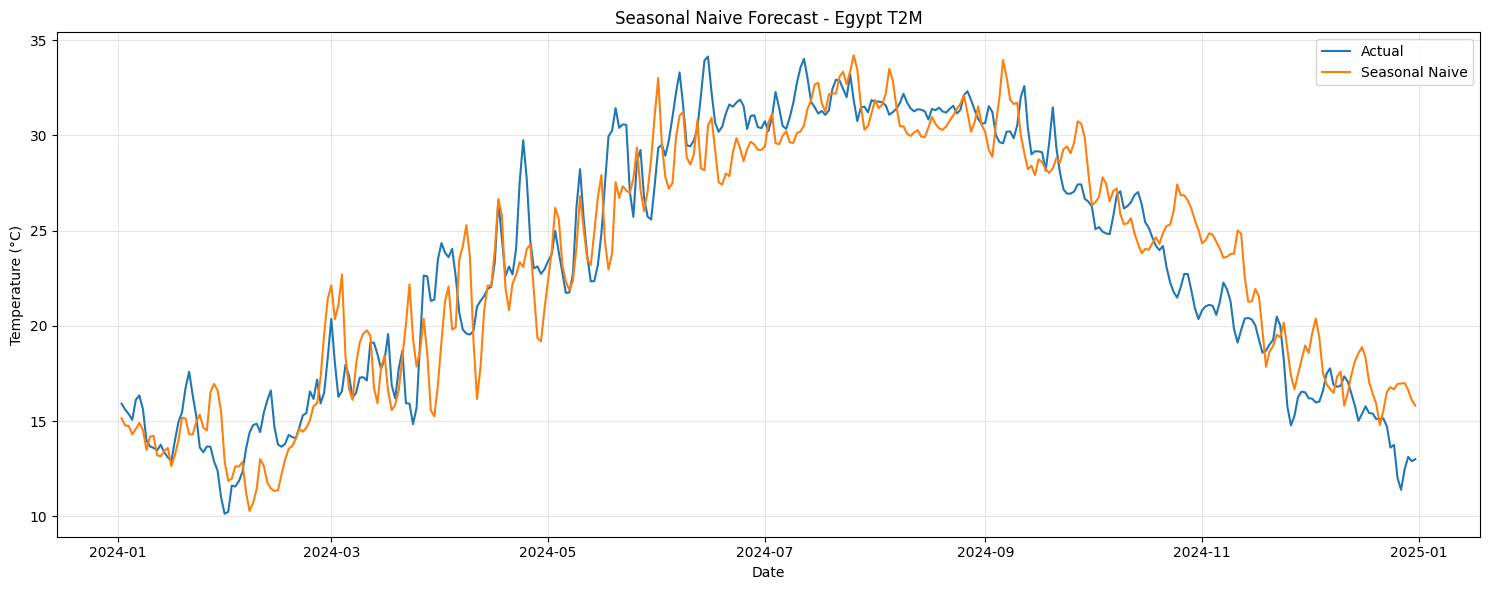

In [43]:
plt.figure(figsize=(15, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    seasonal_naive.index,
    seasonal_naive.values,
    label="Seasonal Naive"
)

plt.title("Seasonal Naive Forecast - Egypt T2M")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [44]:
# LSTM — Egypt-wide T2M Forecasting

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# 1. Create Egypt-wide daily T2M series

egypt_t2m = (
    df.groupby("Date")["T2M"]
      .mean()
      .sort_index()
)

egypt_t2m = egypt_t2m.asfreq("D")

print("Shape:", egypt_t2m.shape)
print("Missing values:", egypt_t2m.isna().sum())
print(egypt_t2m.head())

Shape: (3653,)
Missing values: 0
Date
2015-01-01    12.496667
2015-01-02    11.764074
2015-01-03    11.258889
2015-01-04    11.133704
2015-01-05    11.675185
Freq: D, Name: T2M, dtype: float64


In [45]:
# 2. Train / Test split

train = egypt_t2m.loc[:'2024-01-01']
test = egypt_t2m.loc['2024-01-02':'2024-12-31']

print("Train period:")
print(train.index.min(), "→", train.index.max())

print("\nTest period:")
print(test.index.min(), "→", test.index.max())

print("\nTrain size:", len(train))
print("Test size:", len(test))

Train period:
2015-01-01 00:00:00 → 2024-01-01 00:00:00

Test period:
2024-01-02 00:00:00 → 2024-12-31 00:00:00

Train size: 3288
Test size: 365


In [46]:
# 3. Scaling

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train.values.reshape(-1, 1)
)

print("Scaled train shape:", train_scaled.shape)

Scaled train shape: (3288, 1)


In [47]:
# 4. Create sequences

LOOKBACK = 365

X_train = []
y_train = []

for i in range(LOOKBACK, len(train_scaled)):
    X_train.append(train_scaled[i-LOOKBACK:i, 0])
    y_train.append(train_scaled[i, 0])

X_train = np.array(X_train)
y_train = np.array(y_train)

# LSTM expects:
# [samples, timesteps, features]

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

X_train shape: (2923, 365, 1)
y_train shape: (2923,)


In [48]:
# 5. Build LSTM model

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([
    LSTM(
        64,
        input_shape=(LOOKBACK, 1),
        return_sequences=False
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

In [49]:
# 6. Train

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 28s 255ms/step - loss: 0.0296 - val_loss: 0.0053
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 38s 224ms/step - loss: 0.0085 - val_loss: 0.0049
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 14s 169ms/step - loss: 0.0079 - val_loss: 0.0077
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - loss: 0.0071 - val_loss: 0.0046
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - loss: 0.0065 - val_loss: 0.0038
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 147ms/step - loss: 0.0060 - val_loss: 0.0036
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 152ms/step - loss: 0.0057 - val_loss: 0.0040
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 148ms/step - loss: 0.0053 - val_loss: 0.0037
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 146ms/step - loss: 0.0052 - val_loss: 0.0040
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - loss: 0.0049 - val_loss: 0.0034
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 13s 155ms/step - loss: 0.0046 - val_loss: 0.0041
Epoch 12/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 19

In [50]:
# 7. Prepare test sequences

combined = pd.concat([train, test])

combined_scaled = scaler.transform(
    combined.values.reshape(-1, 1)
)

test_start_idx = len(train)

X_test = []

for i in range(
    test_start_idx,
    len(combined_scaled)
):
    X_test.append(
        combined_scaled[i-LOOKBACK:i, 0]
    )

X_test = np.array(X_test)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

print("X_test shape:", X_test.shape)

X_test shape: (365, 365, 1)


In [51]:
# 8. Forecast

pred_scaled = model.predict(
    X_test,
    verbose=0
)

predictions = scaler.inverse_transform(
    pred_scaled
).flatten()

print("Number of predictions:", len(predictions))

Number of predictions: 365


In [52]:
# 9. Evaluation

mae = mean_absolute_error(
    test.values,
    predictions
)

rmse = np.sqrt(
    mean_squared_error(
        test.values,
        predictions
    )
)

print("=" * 50)
print("LSTM FORECAST")
print("=" * 50)

print(f"MAE  : {mae:.4f} °C")
print(f"RMSE : {rmse:.4f} °C")

LSTM FORECAST
MAE  : 0.6590 °C
RMSE : 0.8978 °C


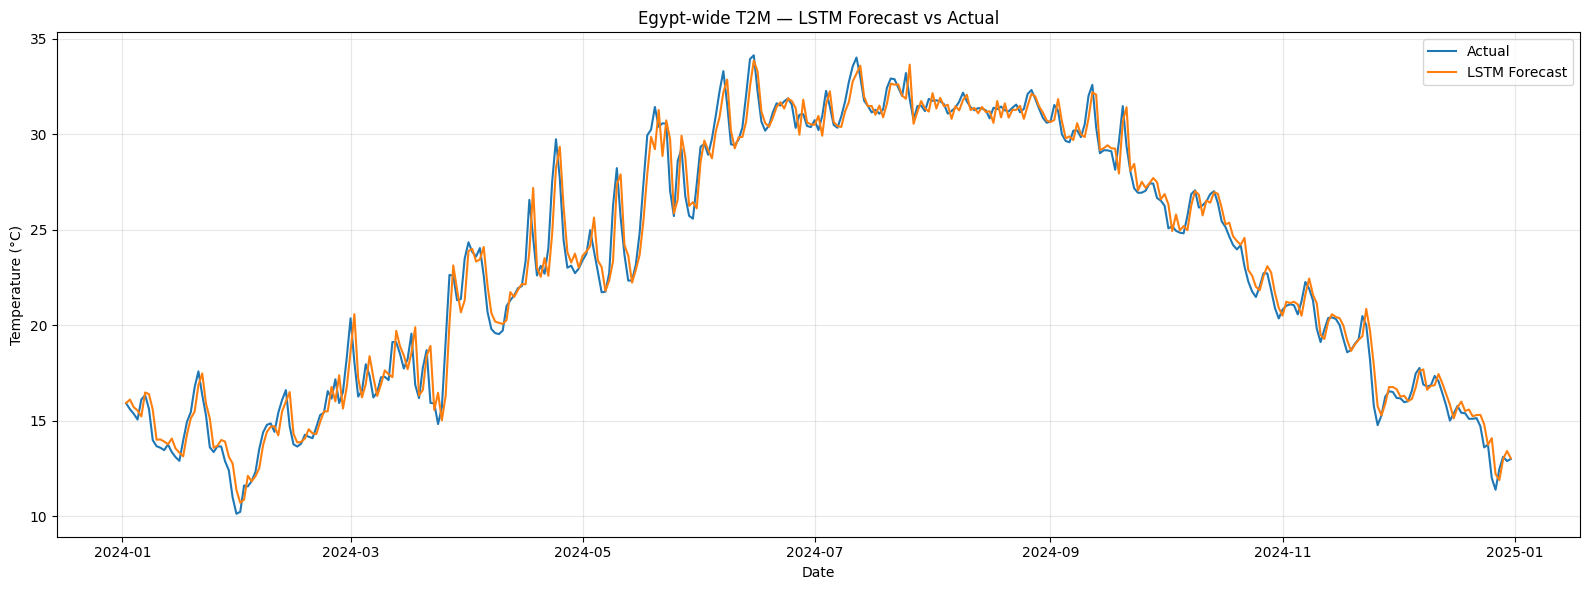

In [53]:
# 10. Plot

plt.figure(figsize=(16, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual",
    linewidth=1.5
)

plt.plot(
    test.index,
    predictions,
    label="LSTM Forecast",
    linewidth=1.5
)

plt.title("Egypt-wide T2M — LSTM Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [54]:
comparison = pd.DataFrame({
    "Actual": test.values,
    "LSTM Forecast": predictions
}, index=test.index)

display(comparison.head(20))

,Actual,LSTM Forecast
Date,,
2024-01-02,15.918519,15.936955
2024-01-03,15.611111,16.113993
2024-01-04,15.371852,15.717534
2024-01-05,15.068889,15.541176
2024-01-06,16.120370,15.236770
2024-01-07,16.346667,16.488764
2024-01-08,15.627778,16.401487
2024-01-09,13.990370,15.590560
2024-01-10,13.673333,14.013459


Shape: (3653,)
Missing values: 0

Train:
2015-01-01 00:00:00 → 2024-01-01 00:00:00
Size: 3288

Test:
2024-01-02 00:00:00 → 2024-12-31 00:00:00
Size: 365

X_train shape: (2923, 365, 1)
y_train shape: (2923,)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_1 (LSTM)                   │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,009 (74.25 KB)

 Trainable params: 19,009 (74.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 16s 149ms/step - loss: 0.0392 - val_loss: 0.0055
Epoch 2/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 147ms/step - loss: 0.0087 - val_loss: 0.0044
Epoch 3/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 145ms/step - loss: 0.0078 - val_loss: 0.0043
Epoch 4/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - loss: 0.0072 - val_loss: 0.0042
Epoch 5/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - loss: 0.0069 - val_loss: 0.0048
Epoch 6/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 146ms/step - loss: 0.0062 - val_loss: 0.0043
Epoch 7/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20s 137ms/step - loss: 0.0063 - val_loss: 0.0041
Epoch 8/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 138ms/step - loss: 0.0056 - val_loss: 0.0052
Epoch 9/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 21s 147ms/step - loss: 0.0053 - val_loss: 0.0040
Epoch 10/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 148ms/step - loss: 0.0050 - val_loss: 0.0035
Epoch 11/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 12s 145ms/step - loss: 0.0049 - val_loss: 0.0037
Epoch 12/50
83/83 ━━━━━━━━━━━━━━━━━━━━ 20

,Actual,LSTM Forecast
Date,,
2024-01-02,15.918519,15.878013
2024-01-03,15.611111,16.010876
2024-01-04,15.371852,16.117567
2024-01-05,15.068889,16.197502
2024-01-06,16.120370,16.255638
2024-01-07,16.346667,16.298029
2024-01-08,15.627778,16.330002
2024-01-09,13.990370,16.355579
2024-01-10,13.673333,16.377525


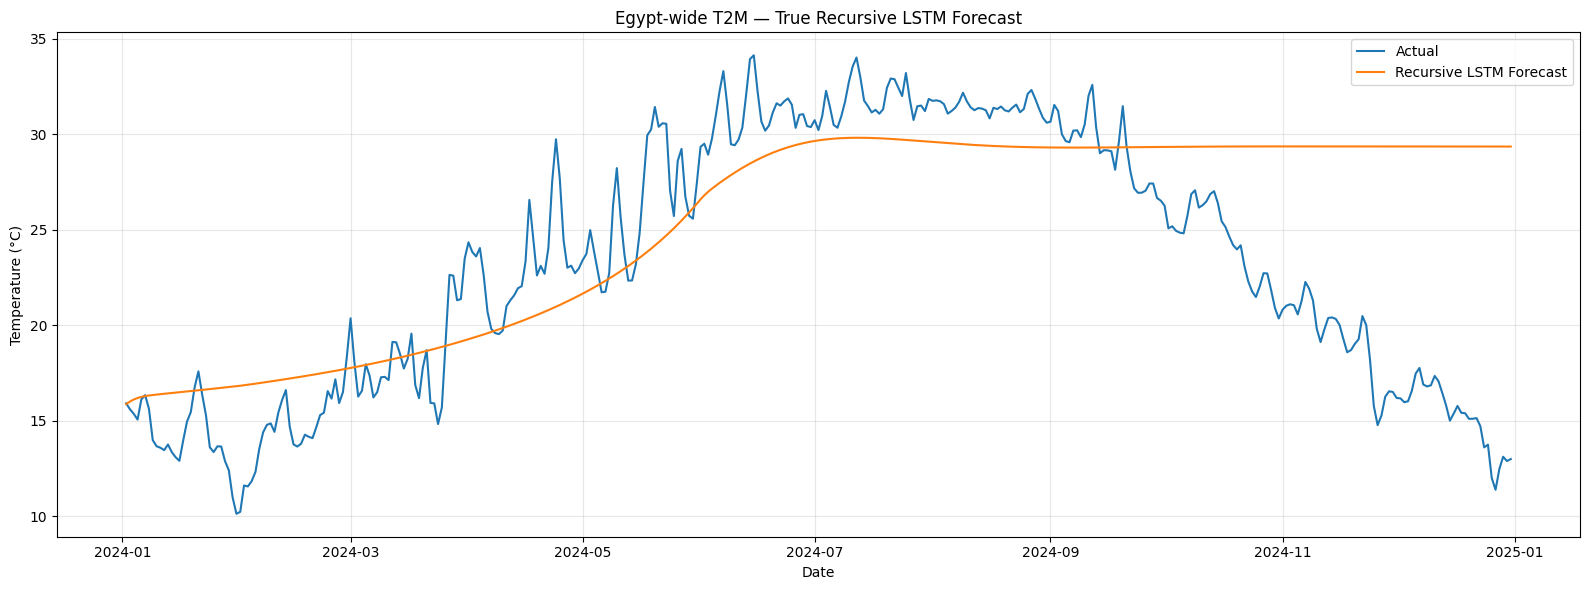

In [55]:
# TRUE 365-DAY RECURSIVE LSTM FORECAST

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping


# 1. Egypt-wide daily T2M

egypt_t2m = (
    df.groupby("Date")["T2M"]
      .mean()
      .sort_index()
      .asfreq("D")
)

print("Shape:", egypt_t2m.shape)
print("Missing values:", egypt_t2m.isna().sum())


# 2. Train / Test split
train = egypt_t2m.loc[:'2024-01-01']
test = egypt_t2m.loc['2024-01-02':'2024-12-31']

print("\nTrain:")
print(train.index.min(), "→", train.index.max())
print("Size:", len(train))

print("\nTest:")
print(test.index.min(), "→", test.index.max())
print("Size:", len(test))


# 3. Scale ONLY using training data

scaler = MinMaxScaler()

train_scaled = scaler.fit_transform(
    train.values.reshape(-1, 1)
)


# 4. Create training sequences

LOOKBACK = 365

X_train = []
y_train = []

for i in range(LOOKBACK, len(train_scaled)):

    X_train.append(
        train_scaled[i-LOOKBACK:i, 0]
    )

    y_train.append(
        train_scaled[i, 0]
    )

X_train = np.array(X_train)
y_train = np.array(y_train)

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

print("\nX_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


# 5. Build LSTM

tf.random.set_seed(42)
np.random.seed(42)

model = Sequential([

    LSTM(
        64,
        input_shape=(LOOKBACK, 1)
    ),

    Dropout(0.2),

    Dense(32, activation="relu"),

    Dense(1)
])

model.compile(
    optimizer="adam",
    loss="mse"
)

model.summary()


# 6. Train

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.1,
    shuffle=False,
    callbacks=[early_stopping],
    verbose=1
)


# 7. TRUE RECURSIVE FORECAST

# Start with the LAST 365 ACTUAL training observations
history_sequence = train_scaled[-LOOKBACK:].flatten().tolist()

predictions_scaled = []

for step in range(len(test)):

    # Last 365 observations
    input_sequence = np.array(
        history_sequence[-LOOKBACK:]
    )

    input_sequence = input_sequence.reshape(
        1,
        LOOKBACK,
        1
    )

    # Predict next day
    next_prediction = model.predict(
        input_sequence,
        verbose=0
    )[0, 0]

    predictions_scaled.append(
        next_prediction
    )

    # IMPORTANT:
    # Add the prediction itself.
    # NOT the actual test value.
    history_sequence.append(
        next_prediction
    )


# 8. Convert predictions back to °C

predictions = scaler.inverse_transform(
    np.array(predictions_scaled).reshape(-1, 1)
).flatten()


print("\nNumber of predictions:", len(predictions))


# 9. Evaluation

lstm_recursive_mae = mean_absolute_error(
    test.values,
    predictions
)

lstm_recursive_rmse = np.sqrt(
    mean_squared_error(
        test.values,
        predictions
    )
)

print("\n" + "=" * 60)
print("TRUE RECURSIVE LSTM FORECAST")
print("=" * 60)

print(f"MAE  : {lstm_recursive_mae:.4f} °C")
print(f"RMSE : {lstm_recursive_rmse:.4f} °C")


# 10. Comparison

lstm_recursive_comparison = pd.DataFrame({
    "Actual": test.values,
    "LSTM Forecast": predictions
}, index=test.index)

display(
    lstm_recursive_comparison.head(20)
)


# 11. Plot

plt.figure(figsize=(16, 6))

plt.plot(
    test.index,
    test.values,
    label="Actual"
)

plt.plot(
    test.index,
    predictions,
    label="Recursive LSTM Forecast"
)

plt.title(
    "Egypt-wide T2M — True Recursive LSTM Forecast"
)

plt.xlabel("Date")
plt.ylabel("Temperature (°C)")

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()